# Fairlearn — Measuring and Mitigating Machine Learning Bias

**Algorithmic fairness** is the study of how machine learning systems can produce outcomes that systematically disadvantage certain demographic groups — and how to detect and reduce those disparities.

A model can appear accurate in aggregate while performing very differently across subpopulations defined by race, gender, age, or other protected attributes. **Fairlearn** is a Python toolkit that makes this audit process rigorous and reproducible.

## The Three Major Fairness Criteria

| Criterion | Intuition | Formula |
|---|---|---|
| **Demographic Parity** | Every group gets positive predictions at the same rate | $P(\hat{Y}=1 \mid A=a) = P(\hat{Y}=1 \mid A=b)$ |
| **Equal Opportunity** | True positive rate (recall) is equal across groups | $P(\hat{Y}=1 \mid Y=1, A=a) = P(\hat{Y}=1 \mid Y=1, A=b)$ |
| **Equalized Odds** | Both TPR *and* FPR are equal across groups | TPR parity **and** FPR parity simultaneously |

> **Impossibility theorem (Chouldechova 2017):** When base rates differ across groups, you *cannot* simultaneously satisfy demographic parity, equalized odds, and calibration. Choosing a fairness criterion is a *value judgment*, not a technical one.

## What This Notebook Covers

1. **Sensitive feature identification** — which attributes define the groups we audit
2. **MetricFrame** — disaggregated accuracy, selection rate, TPR, and FPR by group
3. **Scalar fairness metrics** — demographic parity difference/ratio, equalized odds difference/ratio
4. **Intersectional analysis** — bias at the intersection of race and gender
5. **ThresholdOptimizer** — post-processing mitigation to satisfy equalized odds
6. **Before vs. after comparison** — visualizing the accuracy–fairness tradeoff

## Dataset — Diabetes Hospital Readmission

We audit a Random Forest classifier predicting **30-day hospital readmission**. The dataset covers 130 US hospitals and contains sensitive attributes (`race`, `gender`, `age`) whose differential treatment by the model we will measure and mitigate.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fairlearn.datasets import fetch_diabetes_hospital
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
)
from fairlearn.postprocessing import ThresholdOptimizer

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler

plt.style.use('dark_background')
pd.set_option('display.max_columns', 100)

## Dataset — Diabetes Hospital Readmission

We use the **Diabetes Hospital Readmission** dataset from the UCI Machine Learning Repository (loaded via `fairlearn`). It contains ten years of clinical care records from 130 US hospitals.

| Property | Value |
|---|---|
| Samples | ~101,766 (we use a balanced sample of 2,000) |
| Features | 22 (after dropping leaky target-derived columns) |
| Target | `readmit_30_days`: 1 = readmitted within 30 days, 0 = not |
| Class balance | ~89% negative, ~11% positive — notable imbalance |

**Sensitive attributes used in this fairness audit:**

| Attribute | Groups | Role in audit |
|---|---|---|
| `race` | AfricanAmerican, Asian, Caucasian, Hispanic, Other | Primary sensitive attribute |
| `gender` | Female, Male | Secondary sensitive attribute |
| `age` | ’30 years or younger’, ’30–60 years’, ‘Over 60 years’ | Secondary sensitive attribute |

> **Important:** These attributes are extracted *before* encoding and kept separate from the model’s feature set. The model does not receive them as inputs. However, correlated clinical variables (diagnosis codes, medication regimens) can act as **proxies**, leading to disparate outcomes even without explicit use of protected attributes.

In [2]:
data = fetch_diabetes_hospital(as_frame=True)

df = pd.concat([data.data, data.target], axis=1)
df

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,'30 years or younger',Other,Referral,1,Other,41,0,1,Diabetes,1,None,None,No,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,'30 years or younger','Discharged to Home',Emergency,3,Missing,59,0,18,Other,9,None,None,Up,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,'30 years or younger','Discharged to Home',Emergency,2,Missing,11,5,13,Other,6,None,None,No,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,2,Missing,44,1,16,Other,7,None,None,Up,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,1,Missing,51,0,8,Other,5,None,None,Steady,Ch,Yes,False,False,False,False,False,NO,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,'Over 60 years',Other,Emergency,3,Missing,51,0,16,Diabetes,9,None,>8,Down,Ch,Yes,True,False,False,False,False,>30,1,0
101762,AfricanAmerican,Female,'Over 60 years',Other,Other,5,Missing,33,3,18,Other,9,None,None,Steady,No,Yes,True,False,False,True,False,NO,0,0
101763,Caucasian,Male,'Over 60 years','Discharged to Home',Emergency,1,Missing,53,0,9,Other,13,None,None,Down,Ch,Yes,True,False,False,False,True,NO,0,0
101764,Caucasian,Female,'Over 60 years',Other,Emergency,10,Other,45,2,21,Other,9,None,None,Up,Ch,Yes,True,False,False,True,False,NO,0,0


In [4]:
n_samp_per_class = 10000
target = 'readmit_30_days'  # binary target (0/1)

vc = df[target].value_counts()
print(f'Class distribution:\n{vc}\n')

df1 = df[df[target] == 0].sample(n_samp_per_class, random_state=42)
df2 = df[df[target] == 1].sample(n_samp_per_class, random_state=42)
df = pd.concat([df1, df2], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Balanced class distribution:\n{df[target].value_counts()}\n')

# Save the raw sensitive features BEFORE one-hot encoding
# Fairlearn MetricFrame needs the original categorical labels (e.g., 'Caucasian'),
# not the encoded binary columns, to produce human-readable group names.
sensitive_raw = df[['race', 'gender', 'age']].copy()

# Drop columns derived from the target (would cause data leakage)
X = df.drop(columns=['readmitted', 'readmit_binary', 'readmit_30_days'])
y = df[target]   # binary 0/1

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

# One-hot encode all categorical features (fine for tree-based models)
X_cat = pd.get_dummies(X, columns=cat_cols, drop_first=True).astype(int)
X = pd.concat([X[num_cols], X_cat], axis=1)

feature_names = X.columns.tolist()
n_feat = len(feature_names)

print(f'Feature matrix shape: {X.shape}')
print(f'Sensitive features saved: {sensitive_raw.columns.tolist()}')
X.head()

Class distribution:
readmit_30_days
0    90409
1    11357
Name: count, dtype: int64

Balanced class distribution:
readmit_30_days
1    10000
0    10000
Name: count, dtype: int64

Feature matrix shape: (20000, 47)
Sensitive features saved: ['race', 'gender', 'age']


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,race_Asian,race_Caucasian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,age_'30-60 years',age_'Over 60 years',discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Missing,medical_specialty_Other,primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,primary_diagnosis_Other,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
0,11,86,5,25,9,11,86,5,25,9,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0
1,3,56,1,8,9,3,56,1,8,9,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,1,0,0,0,0,0
2,1,15,2,5,5,1,15,2,5,5,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,1,1,1,0,0,0,0
3,4,56,2,32,9,4,56,2,32,9,0,1,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,0,1,1,0,0,0,0,0
4,3,45,0,20,9,3,45,0,20,9,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,0,1,1,1,0


## Baseline Classification Model

We train a **Random Forest** classifier on the encoded feature set. This is our **baseline model** whose fairness we will audit in all subsequent sections.

The model does *not* receive `race`, `gender`, or `age` as explicit inputs — the one-hot encoder replaced them with anonymous binary columns. Despite this, the model may learn correlated clinical proxies that produce disparate outcomes. This phenomenon is called **proxy discrimination** and is one of the most common real-world fairness failures.

We oversample the minority class in the training fold only (to handle class imbalance), then evaluate on the original held-out test set.

In [5]:
# Pass sensitive_raw through the split so it stays perfectly aligned with X and y.
# Using train_test_split with multiple arrays guarantees identical row ordering.
X_train, X_test, y_train, y_test, sf_train, sf_test = train_test_split(
    X, y, sensitive_raw,
    test_size=0.2, stratify=y, random_state=42
)

# Reset indices to 0-based so Fairlearn can align arrays reliably
X_train  = X_train.reset_index(drop=True)
X_test   = X_test.reset_index(drop=True)
y_train  = y_train.reset_index(drop=True)
y_test   = y_test.reset_index(drop=True)
sf_train = sf_train.reset_index(drop=True)
sf_test  = sf_test.reset_index(drop=True)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'sf_train: {sf_train.shape}  |  sf_test: {sf_test.shape}')

Train: (16000, 47)  |  Test: (4000, 47)
sf_train: (16000, 3)  |  sf_test: (4000, 3)


In [6]:
# Oversample the minority class in the training fold only
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# Train the baseline Random Forest
model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train_res, y_train_res)

# Baseline predictions on the held-out test set
y_pred = model.predict(X_test)

print('=== BASELINE MODEL ===')
print(f'Training shape: {y_train.value_counts().to_dict()}')
print(f'Resampled shape: {y_train_res.value_counts().to_dict()}\n')
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))

=== BASELINE MODEL ===
Training shape: {1: 8000, 0: 8000}
Resampled shape: {1: 8000, 0: 8000}

                precision    recall  f1-score   support

Not Readmitted       0.58      0.56      0.57      2000
    Readmitted       0.58      0.60      0.59      2000

      accuracy                           0.58      4000
     macro avg       0.58      0.58      0.58      4000
  weighted avg       0.58      0.58      0.58      4000



---

## Fairness Criteria in Depth

Before auditing the model, we define the metrics precisely. Let $\hat{Y}$ be the model’s prediction, $Y$ the ground truth, and $A$ a sensitive attribute.

### Demographic Parity

All groups should receive the positive prediction at the same rate:
$$\text{DP difference} = \max_a P(\hat{Y}=1 \mid A=a) - \min_a P(\hat{Y}=1 \mid A=a)$$

This criterion is *output-focused* — it cares about the distribution of predictions, not whether they are correct.

### Equal Opportunity

Among patients who *were* readmitted ($Y=1$), every group should have equal recall:
$$\text{TPR difference} = \max_a P(\hat{Y}=1 \mid Y=1, A=a) - \min_a P(\hat{Y}=1 \mid Y=1, A=a)$$

This is the right criterion when **false negatives are the costly error** (e.g., missing a high-risk patient).

### Equalized Odds

Both the true positive rate *and* the false positive rate must be equal across groups:
$$\text{EO difference} = \max\left(\text{TPR difference},\ \text{FPR difference}\right)$$

This is strictly stronger than equal opportunity. It ensures no group is disproportionately flagged (high FPR) *or* missed (low TPR).

### Difference vs. Ratio

Fairlearn reports fairness gaps as both a **difference** and a **ratio**:

| Metric form | Formula | Ideal value | Common threshold |
|---|---|---|---|
| Difference | $\max - \min$ across groups | 0 | $\leq 0.10$ |
| Ratio | $\min / \max$ across groups | 1 | $\geq 0.80$ (the ‘80% rule’) |

---

## Section 1 — Sensitive Feature Distributions

A fairness audit begins with population accounting: how many individuals from each group appear in the test set? Small groups yield high-variance metric estimates — keep group sizes in mind when interpreting results.

In [18]:
# Reusable color palette for all plots in this notebook
colors = plt.cm.tab10.colors

---

## Section 2 — MetricFrame: Disaggregated Metrics by Group

`MetricFrame` is Fairlearn’s primary audit tool. It takes any set of sklearn-compatible metric functions and evaluates each one **separately for every group** defined by a sensitive feature.

### Key properties

| Property / Method | Description |
|---|---|
| `.overall` | Metrics computed on the full dataset (ignoring groups) |
| `.by_group` | Metrics broken out per group as a DataFrame |
| `.difference()` | Max − min across groups per metric (0 = perfect parity) |
| `.ratio()` | Min / max across groups per metric (1 = perfect parity) |

### Metrics we audit

| Metric | Fairness concern it addresses |
|---|---|
| **Accuracy** | Are some groups harder to classify correctly? |
| **Selection rate** | Does the model favor certain groups with positive predictions? |
| **True positive rate** | Does the model miss readmissions more in some groups? |
| **False positive rate** | Does the model over-flag certain groups as at-risk? |

We run separate MetricFrame instances for `race`, `gender`, and `age`.

In [19]:
#'race', 'gender', 'age'
col = 'race'
counts = sf_test[col].value_counts()
pcts   = (counts / len(sf_test) * 100).round(1)
summary = pd.DataFrame({'count': counts, 'pct (%)': pcts})
print(f'--- {col.upper()} ---')
print(summary.to_string())
print()

# Define the set of metrics once and reuse across all MetricFrame calls
metrics_dict = {
    'accuracy':            accuracy_score,
    'selection_rate':      selection_rate,
    'true_positive_rate':  true_positive_rate,
    'false_positive_rate': false_positive_rate,
}

# --- Audit by RACE ---
mf_race = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sf_test['race']
)

print('=== METRICS BY RACE ===')
print('\nOverall (full test set):')
print(mf_race.overall.round(3).to_string())
print('\nDisaggregated by race:')
print(mf_race.by_group.round(3).sort_values('accuracy', ascending=False).to_string())
print('\nDifference (max − min):')
print(mf_race.difference().round(3).to_string())
print('\nRatio (min / max):')
print(mf_race.ratio().round(3).to_string())

--- RACE ---
                 count  pct (%)
race                           
Caucasian         3017     75.4
AfricanAmerican    748     18.7
Unknown             90      2.2
Hispanic            76      1.9
Other               48      1.2
Asian               21      0.5

=== METRICS BY RACE ===

Overall (full test set):
accuracy               0.581
selection_rate         0.517
true_positive_rate     0.598
false_positive_rate    0.436

Disaggregated by race:
                 accuracy  selection_rate  true_positive_rate  false_positive_rate
race                                                                              
Hispanic            0.671           0.500               0.686                0.341
Asian               0.667           0.476               0.615                0.250
Unknown             0.644           0.267               0.382                0.196
Other               0.583           0.375               0.458                0.292
Caucasian           0.579           0.526 

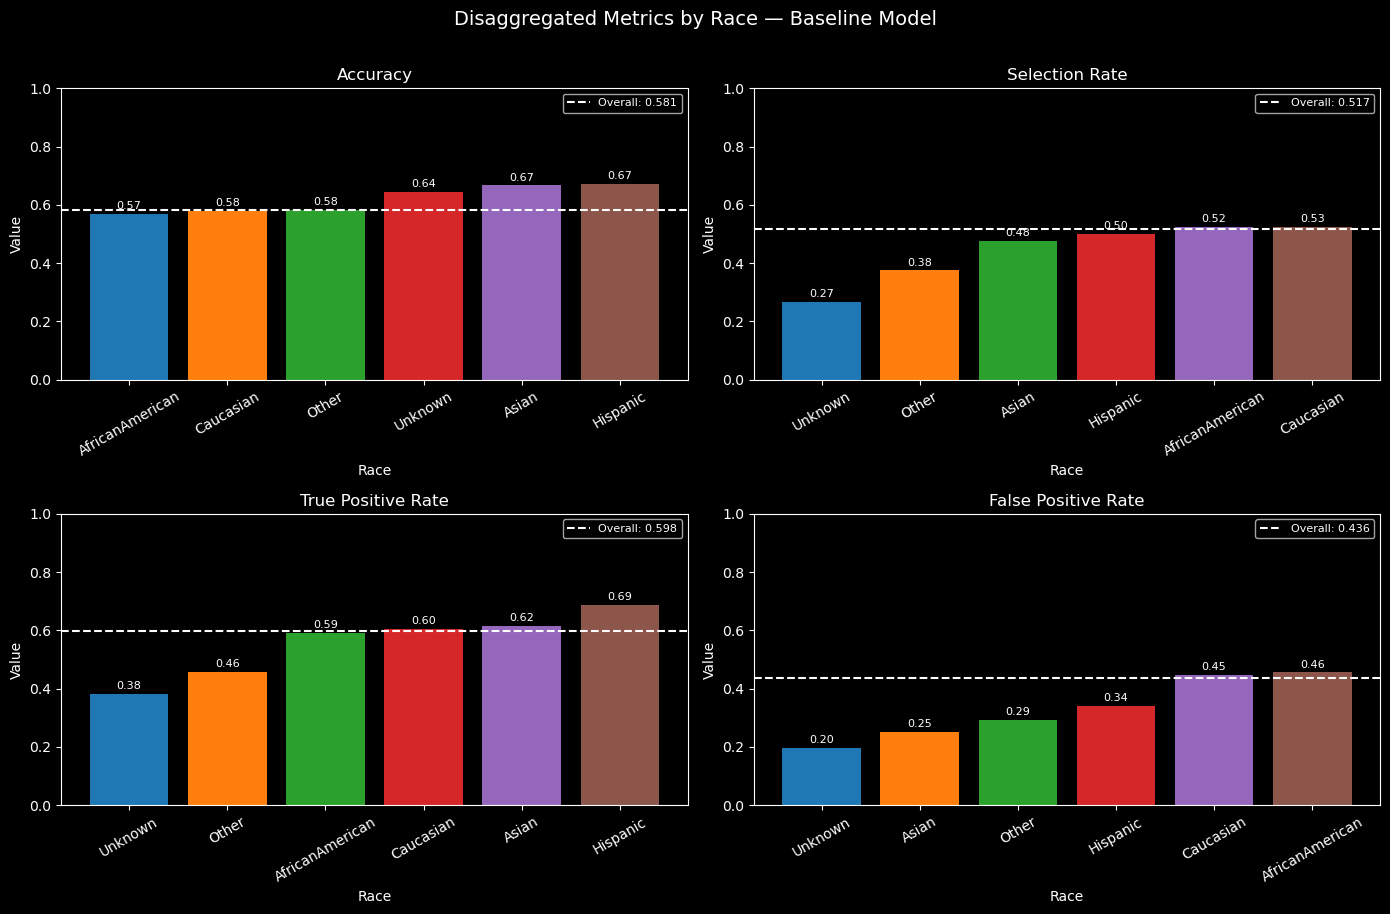

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Disaggregated Metrics by Race — Baseline Model', fontsize=14, y=1.01)

for ax, metric in zip(axes.flat, metrics_dict.keys()):
    vals = mf_race.by_group[metric].sort_values()
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)])
    ax.axhline(mf_race.overall[metric], color='white', linestyle='--', linewidth=1.5,
               label=f'Overall: {mf_race.overall[metric]:.3f}')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Race')
    ax.set_ylabel('Value')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [20]:
#'race', 'gender', 'age'
col = 'gender'
counts = sf_test[col].value_counts()
pcts   = (counts / len(sf_test) * 100).round(1)
summary = pd.DataFrame({'count': counts, 'pct (%)': pcts})
print(f'--- {col.upper()} ---')
print(summary.to_string())
print()

# --- Audit by GENDER ---
mf_gender = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sf_test['gender']
)

print('=== METRICS BY GENDER ===')
print('\nOverall:')
print(mf_gender.overall.round(3).to_string())
print('\nDisaggregated by gender:')
print(mf_gender.by_group.round(3).sort_values('accuracy', ascending=False).to_string())
print('\nDifference (max − min):')
print(mf_gender.difference().round(3).to_string())
print('\nRatio (min / max):')
print(mf_gender.ratio().round(3).to_string())

--- GENDER ---
                 count  pct (%)
gender                         
Female            2165     54.1
Male              1834     45.8
Unknown/Invalid      1      0.0

=== METRICS BY GENDER ===

Overall:
accuracy               0.581
selection_rate         0.517
true_positive_rate     0.598
false_positive_rate    0.436

Disaggregated by gender:
                 accuracy  selection_rate  true_positive_rate  false_positive_rate
gender                                                                            
Unknown/Invalid     1.000           0.000               0.000                0.000
Male                0.591           0.514               0.604                0.423
Female              0.573           0.520               0.593                0.447

Difference (max − min):
accuracy               0.427
selection_rate         0.520
true_positive_rate     0.604
false_positive_rate    0.447

Ratio (min / max):
accuracy               0.573
selection_rate         0.000
true_positiv

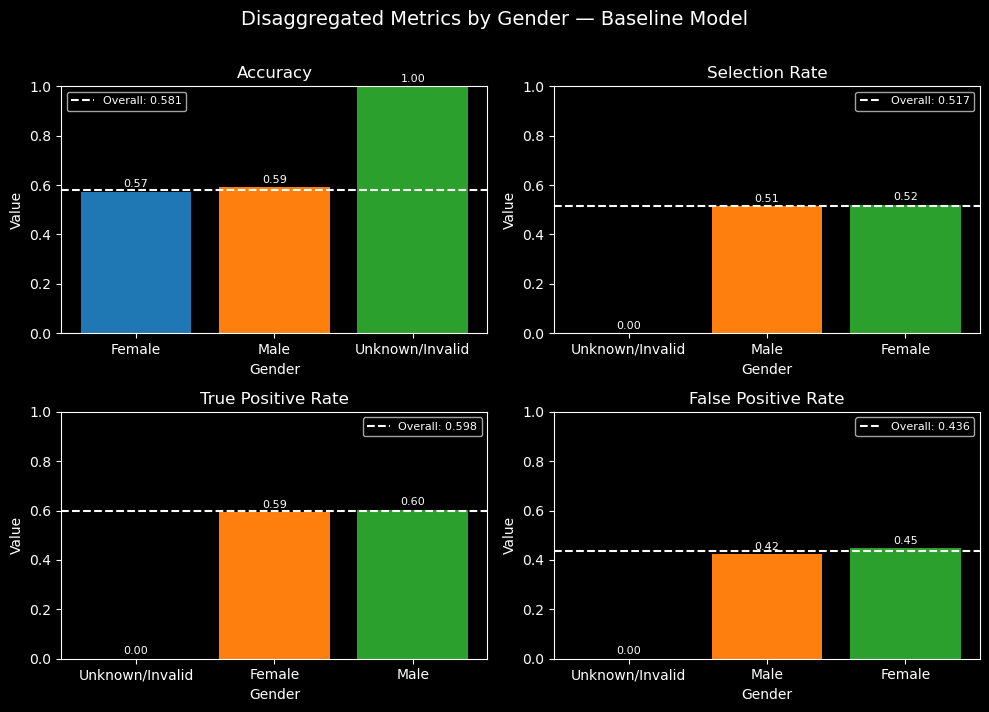

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Disaggregated Metrics by Gender — Baseline Model', fontsize=14, y=1.01)

for ax, metric in zip(axes.flat, metrics_dict.keys()):
    vals = mf_gender.by_group[metric].sort_values()
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)])
    ax.axhline(mf_gender.overall[metric], color='white', linestyle='--', linewidth=1.5,
               label=f'Overall: {mf_gender.overall[metric]:.3f}')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Gender')
    ax.set_ylabel('Value')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
#'race', 'gender', 'age'
col = 'age'
counts = sf_test[col].value_counts()
pcts   = (counts / len(sf_test) * 100).round(1)
summary = pd.DataFrame({'count': counts, 'pct (%)': pcts})
print(f'--- {col.upper()} ---')
print(summary.to_string())
print()

# --- Audit by AGE ---
mf_age = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sf_test['age']
)

print('=== METRICS BY AGE GROUP ===')
print('\nOverall:')
print(mf_age.overall.round(3).to_string())
print('\nDisaggregated by age:')
print(mf_age.by_group.round(3).to_string())
print('\nDifference (max − min):')
print(mf_age.difference().round(3).to_string())
print('\nRatio (min / max):')
print(mf_age.ratio().round(3).to_string())

--- AGE ---
                       count  pct (%)
age                                  
'Over 60 years'         2745     68.6
'30-60 years'           1162     29.0
'30 years or younger'     93      2.3

=== METRICS BY AGE GROUP ===

Overall:
accuracy               0.581
selection_rate         0.517
true_positive_rate     0.598
false_positive_rate    0.436

Disaggregated by age:
                       accuracy  selection_rate  true_positive_rate  false_positive_rate
age                                                                                     
'30 years or younger'     0.591           0.452               0.545                0.367
'30-60 years'             0.628           0.448               0.582                0.331
'Over 60 years'           0.561           0.548               0.606                0.487

Difference (max − min):
accuracy               0.068
selection_rate         0.100
true_positive_rate     0.060
false_positive_rate    0.156

Ratio (min / max):
accuracy     

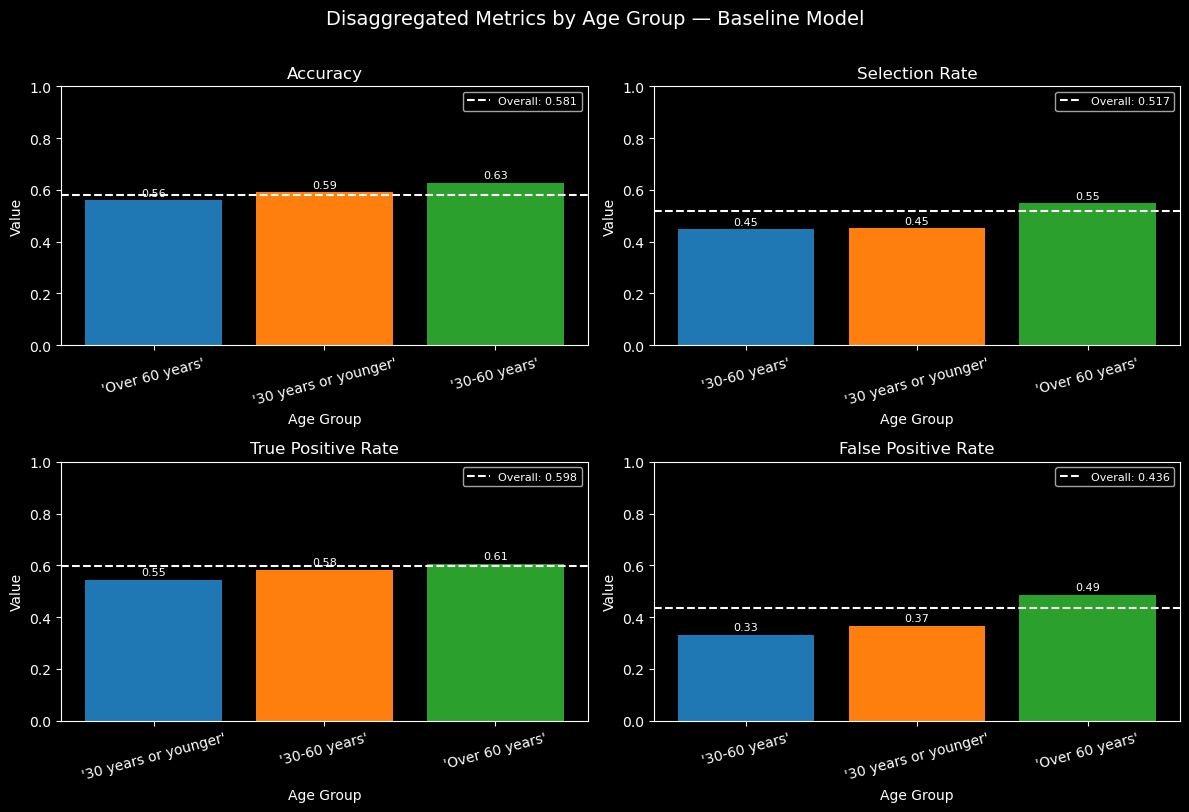

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Disaggregated Metrics by Age Group — Baseline Model', fontsize=14, y=1.01)

for ax, metric in zip(axes.flat, metrics_dict.keys()):
    vals = mf_age.by_group[metric].sort_values()
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)])
    ax.axhline(mf_age.overall[metric], color='white', linestyle='--', linewidth=1.5,
               label=f'Overall: {mf_age.overall[metric]:.3f}')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Value')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---

## Section 3 — Scalar Fairness Metrics

MetricFrame tables show the full picture, but practitioners often need a **single number** to compare models or set pass/fail thresholds. Fairlearn provides scalar summary functions for the most important fairness criteria.

| Function | Measures | Ideal |
|---|---|---|
| `demographic_parity_difference` | Gap in positive prediction rates | 0 |
| `demographic_parity_ratio` | Ratio of lowest to highest selection rate | 1 |
| `equalized_odds_difference` | Max of (TPR gap, FPR gap) across groups | 0 |
| `equalized_odds_ratio` | Min of (TPR ratio, FPR ratio) across groups | 1 |

We compute these for all three sensitive attributes and assemble a summary table for easy comparison.

### Interpretation guide
- **Difference ≤ 0.10** → generally considered acceptable in practice
- **Ratio ≥ 0.80** → the ‘80% rule’ from US employment law (Uniform Guidelines on Employee Selection Procedures)

In [23]:
sensitive_cols = ['race', 'gender', 'age']
rows = []

for col in sensitive_cols:
    sf = sf_test[col]
    rows.append({
        'sensitive_feature': col,
        'dp_difference':  round(demographic_parity_difference(y_test, y_pred, sensitive_features=sf), 4),
        'dp_ratio':       round(demographic_parity_ratio(y_test, y_pred, sensitive_features=sf), 4),
        'eo_difference':  round(equalized_odds_difference(y_test, y_pred, sensitive_features=sf), 4),
        'eo_ratio':       round(equalized_odds_ratio(y_test, y_pred, sensitive_features=sf), 4),
    })

scalar_df = pd.DataFrame(rows).set_index('sensitive_feature')
print('=== SCALAR FAIRNESS METRICS — BASELINE MODEL ===')
print(scalar_df.to_string())
print()
print('Reference:  difference ≤ 0.10 = acceptable  |  ratio ≥ 0.80 = 80% rule')

=== SCALAR FAIRNESS METRICS — BASELINE MODEL ===
                   dp_difference  dp_ratio  eo_difference  eo_ratio
sensitive_feature                                                  
race                      0.2590    0.5073         0.3034    0.4312
gender                    0.5196    0.0000         0.6043    0.0000
age                       0.0999    0.8178         0.1561    0.6797

Reference:  difference ≤ 0.10 = acceptable  |  ratio ≥ 0.80 = 80% rule


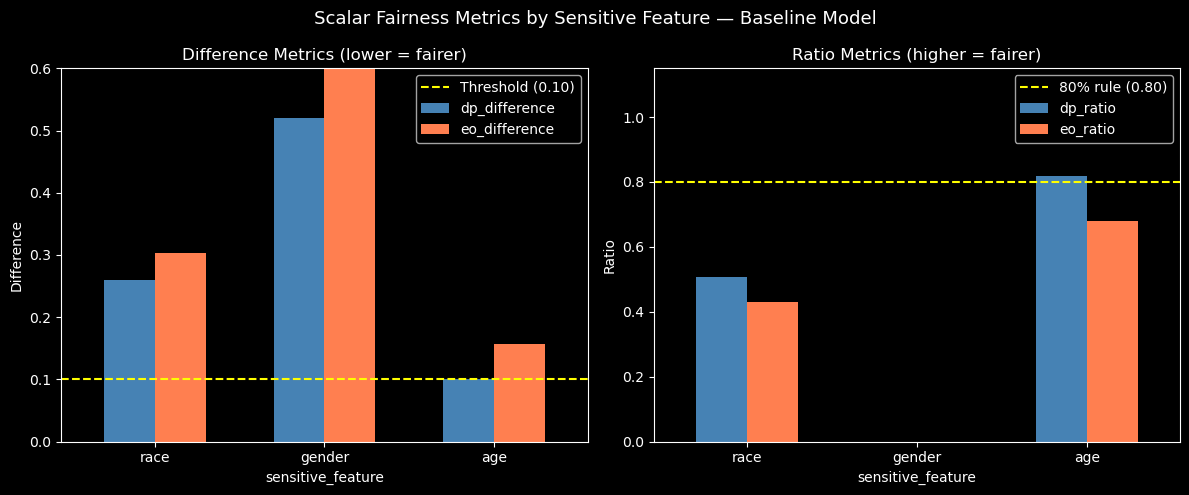

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Scalar Fairness Metrics by Sensitive Feature — Baseline Model', fontsize=13)

# Difference metrics (lower = fairer)
scalar_df[['dp_difference', 'eo_difference']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], width=0.6
)
axes[0].axhline(0.10, color='yellow', linestyle='--', linewidth=1.5, label='Threshold (0.10)')
axes[0].set_title('Difference Metrics (lower = fairer)')
axes[0].set_ylabel('Difference')
axes[0].set_ylim(0, 0.6)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

# Ratio metrics (higher = fairer)
scalar_df[['dp_ratio', 'eo_ratio']].plot(
    kind='bar', ax=axes[1], color=['steelblue', 'coral'], width=0.6
)
axes[1].axhline(0.80, color='yellow', linestyle='--', linewidth=1.5, label='80% rule (0.80)')
axes[1].set_title('Ratio Metrics (higher = fairer)')
axes[1].set_ylabel('Ratio')
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

---

## Section 4 — Intersectional Fairness Analysis

Single-attribute audits can **mask discrimination** that only appears at the intersection of multiple protected characteristics — a phenomenon studied by legal scholar Kimberlé Crenshaw under the term *intersectionality*.

**Why intersectional analysis matters:**
- A race audit might show small disparities between Black and white patients overall
- A gender audit might also look acceptable
- But *Black women* specifically could face a far larger disadvantage, hidden because white women and Black men bring the group averages closer together

We create a combined `race × gender` label and audit at that granularity. This surface has more groups and smaller counts per cell — interpret with appropriate caution for small groups.

In [27]:
sf_test_inter = sf_test.copy()
sf_test_inter['race_x_gender'] = (
    sf_test_inter['race'].str.strip("'") + ' / ' + sf_test_inter['gender']
)

mf_inter = MetricFrame(
    metrics={
        'accuracy':            accuracy_score,
        'selection_rate':      selection_rate,
        'true_positive_rate':  true_positive_rate,
        'false_positive_rate': false_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sf_test_inter['race_x_gender']
)

print('=== INTERSECTIONAL ANALYSIS: Race × Gender ===')
print('\nDisaggregated metrics:')
print(mf_inter.by_group.round(3).sort_values('accuracy', ascending=False).to_string())
print('\nDifferences (max − min):')
print(mf_inter.difference().round(3).to_string())

=== INTERSECTIONAL ANALYSIS: Race × Gender ===

Disaggregated metrics:
                           accuracy  selection_rate  true_positive_rate  false_positive_rate
race_x_gender                                                                               
Unknown / Unknown/Invalid     1.000           0.000               0.000                0.000
Asian / Female                0.800           0.600               0.833                0.250
Hispanic / Female             0.692           0.513               0.786                0.360
Other / Female                0.679           0.357               0.533                0.154
Unknown / Male                0.651           0.349               0.500                0.259
Hispanic / Male               0.649           0.486               0.619                0.312
Unknown / Female              0.630           0.196               0.278                0.143
Caucasian / Male              0.592           0.519               0.610                0.426

In [ ]:
by_group_inter = mf_inter.by_group.sort_values('selection_rate', ascending=False)
n_groups = len(by_group_inter)

inter_metrics  = ['selection_rate', 'true_positive_rate', 'false_positive_rate']
inter_colors   = ['steelblue', 'seagreen', 'coral']
inter_titles   = ['Selection Rate', 'True Positive Rate', 'False Positive Rate']

fig, axes = plt.subplots(3, 1, figsize=(14, 13))
fig.suptitle('Intersectional Fairness: Race × Gender — Baseline Model', fontsize=14, y=1.01)

for ax, metric, color, title in zip(axes, inter_metrics, inter_colors, inter_titles):
    vals = by_group_inter[metric]
    bars = ax.bar(range(n_groups), vals.values, color=color, alpha=0.85)
    ax.axhline(mf_inter.overall[metric], color='white', linestyle='--', linewidth=1.2,
               label=f'Overall: {mf_inter.overall[metric]:.3f}')
    ax.set_xticks(range(n_groups))
    ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('Value')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

---

## Section 5 — Fairness-Aware Mitigation: ThresholdOptimizer

### Three families of mitigation

| Family | Timing | Mechanism |
|---|---|---|
| **Pre-processing** | Before training | Reweight or resample training data to reduce representation bias |
| **In-processing** | During training | Add a fairness constraint to the optimization objective (e.g., `ExponentiatedGradient`) |
| **Post-processing** | After training | Adjust decision thresholds per group to meet a fairness constraint |

We use **post-processing** via `ThresholdOptimizer` because it leaves the base model completely untouched — ideal when the training pipeline cannot be modified.

### How ThresholdOptimizer works

1. Takes an already-fitted classifier with `predict_proba`
2. Finds the optimal **per-group decision threshold** that minimizes a performance objective (here: `balanced_accuracy_score`)
3. Subject to satisfying a specified **fairness constraint** (here: `equalized_odds` on race)

At inference time it applies the group-specific threshold rather than the global 0.5 default.

**Advantages:** No retraining, works on any probabilistic classifier, interpretable  
**Limitations:** Requires sensitive attribute values at inference time; can only reduce disparity, not overcome a fundamentally biased model

In [ ]:
mitigator = ThresholdOptimizer(
    estimator=model,
    constraints='equalized_odds',
    predict_method='predict_proba',
    objective='balanced_accuracy_score'
)

# Fit the threshold optimizer on the original (non-oversampled) training fold
# It uses the already-trained model to generate probabilities, then searches
# for group-specific thresholds that satisfy the equalized_odds constraint.
mitigator.fit(X_train, y_train, sensitive_features=sf_train['race'])

# Apply group-specific thresholds at prediction time
y_pred_mit = mitigator.predict(X_test, sensitive_features=sf_test['race'])

print('=== MITIGATED MODEL (ThresholdOptimizer — equalized_odds on race) ===')
print(classification_report(y_test, y_pred_mit, target_names=['Not Readmitted', 'Readmitted']))

In [ ]:
# Re-run MetricFrame on the mitigated predictions to see the post-mitigation disparity
mf_race_mit = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=y_pred_mit,
    sensitive_features=sf_test['race']
)

print('=== MITIGATED MODEL — Disaggregated Metrics by Race ===')
print('\nOverall:')
print(mf_race_mit.overall.round(3).to_string())
print('\nBy group:')
print(mf_race_mit.by_group.round(3).to_string())
print('\nDifferences (max − min):')
print(mf_race_mit.difference().round(3).to_string())

---

## Section 6 — Before vs. After: The Accuracy–Fairness Tradeoff

Fairness mitigation almost never comes free. Applying equalized-odds constraints forces the model to sacrifice some accuracy on *over-privileged* groups in order to give *under-privileged* groups better treatment.

The plots below compare:
- **Baseline** — vanilla Random Forest, no fairness intervention
- **Mitigated** — same model + ThresholdOptimizer (equalized odds constraint on race)

We compare aggregate performance *and* the group-level disparity that each configuration produces. The TPR-by-race panel makes the equalization effect visually concrete.

In [ ]:
# Build scalar comparison table
comparison = pd.DataFrame({
    'model':           ['Baseline', 'Mitigated'],
    'accuracy':        [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_mit)
    ],
    'dp_diff (race)':  [
        demographic_parity_difference(y_test, y_pred,     sensitive_features=sf_test['race']),
        demographic_parity_difference(y_test, y_pred_mit, sensitive_features=sf_test['race'])
    ],
    'eo_diff (race)':  [
        equalized_odds_difference(y_test, y_pred,     sensitive_features=sf_test['race']),
        equalized_odds_difference(y_test, y_pred_mit, sensitive_features=sf_test['race'])
    ],
}).set_index('model').round(4)

print('=== BASELINE vs. MITIGATED ===')
print(comparison.to_string())

# --- Scalar comparison bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Baseline vs. Mitigated — Accuracy & Fairness Metrics', fontsize=14)

bar_colors = ['steelblue', 'coral']
metrics_to_show = ['accuracy', 'dp_diff (race)', 'eo_diff (race)']
titles_show     = [
    'Accuracy\n(higher = better)',
    'DP Difference (race)\n(lower = fairer)',
    'EO Difference (race)\n(lower = fairer)'
]

for ax, metric, title in zip(axes, metrics_to_show, titles_show):
    vals = comparison[metric]
    bars = ax.bar(vals.index, vals.values, color=bar_colors, width=0.5)
    ax.set_title(title)
    ax.set_ylim(0, max(vals.max() * 1.3, 0.05))
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# --- TPR by race: Baseline vs. Mitigated ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('True Positive Rate by Race: Baseline vs. Mitigated', fontsize=13)

for ax, (label, mf) in zip(axes, [('Baseline', mf_race), ('Mitigated', mf_race_mit)]):
    tpr_vals = mf.by_group['true_positive_rate'].sort_values()
    bars = ax.bar(tpr_vals.index, tpr_vals.values, color=colors[:len(tpr_vals)])
    ax.axhline(mf.overall['true_positive_rate'], color='white', linestyle='--',
               linewidth=1.5, label=f'Overall: {mf.overall["true_positive_rate"]:.3f}')
    ax.set_title(label)
    ax.set_xlabel('Race')
    ax.set_ylabel('True Positive Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    for bar, val in zip(bars, tpr_vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---

## Summary

### Fairlearn Tools Used

| Tool | Module | Purpose |
|---|---|---|
| `MetricFrame` | `fairlearn.metrics` | Disaggregated audit — full metric table per group, with difference and ratio summaries |
| `demographic_parity_difference/ratio` | `fairlearn.metrics` | Scalar: is the positive prediction rate equal across groups? |
| `equalized_odds_difference/ratio` | `fairlearn.metrics` | Scalar: are both TPR and FPR equal across groups? |
| `ThresholdOptimizer` | `fairlearn.postprocessing` | Post-processing mitigation via group-specific decision thresholds |

### Fairness Criteria Recap

| Criterion | Measures | Best for |
|---|---|---|
| Demographic Parity | Selection rate equality | Output quota contexts (hiring, lending, admissions) |
| Equal Opportunity | Recall (TPR) equality | High false-negative cost (medical screening, recidivism) |
| Equalized Odds | Both TPR + FPR equality | When both error types have serious, asymmetric consequences |

### The Fairlearn Audit Workflow

```
1. Identify sensitive attributes (race, gender, age …)
2. Audit with MetricFrame → see WHICH groups are affected and by HOW MUCH
3. Compute scalar metrics → quantify the gap with a single number per criterion
4. Run intersectional analysis → detect hidden compounded disadvantages
5. Select a mitigation strategy → pre-, in-, or post-processing
6. Re-audit the mitigated model → verify improvement, monitor accuracy tradeoff
7. Document choices → fairness criterion selection is a VALUE JUDGMENT, not a technical one
```

### Core Identities
- Difference of 0 → perfect parity (all groups treated identically)
- Ratio of 1 → perfect parity (minority group gets 100% of majority group’s rate)
- Fairness and accuracy exist in tension — improvement in one typically costs the other
- No single criterion is universally correct; the right choice depends on which errors cause the most harm in your context